In [3]:
import numpy as np
import matplotlib.pyplot as plt

### Processo di Wiener (moto browniano standard)

Un processo di Wiener $W_t$ è un processo stocastico che soddisfa le seguenti proprietà:

1. $W_0=0$.
2. Gli incrementi $W_{t+s}-W_t$ sono stazionari e indipendenti.
3. Per $s>0$,

$$
W_{t+s}-W_t\sim\mathcal N(0,s).
$$

L'ultima condizione implica che

$$
W_t\sim\mathcal N(0,t),
$$

con $t\geq0$.

---

### Moto browniano non standard

Un processo stocastico $X_t$ è detto moto browniano non standard se è soluzione dell'equazione di Itô

$$
dX_t=\mu\,dt+\sigma\,dW_t,
$$

dove $W_t$ è un processo di Wiener, \mu è il drift e $\sigma$ è la volatilità.

Integrando tra $0$ e $t$, si ottiene

$$
X_t=X_0+\mu t+\sigma W_t.
$$

Pertanto,

$$
X_t\sim\mathcal N(X_0+\mu t,\sigma^2t).
$$

---

### Moto browniano geometrico

Un processo stocastico $S_t$ è detto moto browniano geometrico se soddisfa l'equazione di Itô

$$
dS_t=\mu S_t\,dt+\sigma S_t\,dW_t,
$$

dove $W_t$ è un processo di Wiener, $\mu$ è il drift e $\sigma$ la volatilità.

Applicando la formula di Itô alla funzione $f(S_t)=\ln S_t$, si ottiene

$$
d\ln S_t=
\left(\mu-\frac{\sigma^2}{2}\right)dt+\sigma\,dW_t.
$$

Quindi $\ln S_t$ segue un moto browniano non standard. Integrando,

$$
\ln S_t
=
\ln S_0+
\left(\mu-\frac{\sigma^2}{2}\right)t
+\sigma W_t,
$$

da cui

$$
\boxed{
S_t=S_0\exp\left[
\left(\mu-\frac{\sigma^2}{2}\right)t+\sigma W_t
\right].
}
$$

In particolare,

$$
S_t\sim
\text{LogNormale}\left(
\ln S_0+\left(\mu-\frac{\sigma^2}{2}\right)t,\,
\sigma^2t
\right).
$$

Nota: nulla vieta di porre $t=T$, ottenendo direttamente il valore del processo al tempo finale:

$$
S_T=S_0\exp\left[
\left(\mu-\frac{\sigma^2}{2}\right)T+\sigma W_T
\right].
$$

---

### Opzioni europee

Il moto browniano geometrico può essere utilizzato, con le dovute approssimazioni, per modellizzare l'andamento dei prezzi degli asset finanziari e, di conseguenza, dei prodotti finanziari.

Ci concentreremo in particolare sulle opzioni europee.

Un'opzione europea è un contratto nel quale una parte, detta writer, concede all'altra parte, detta holder, il diritto, ma non l'obbligo, di:

* acquistare l'asset a un prezzo prefissato $K$ strike price: call option;
* vendere l'asset a un prezzo prefissato $K$: put option.

Il contratto può essere esercitato esclusivamente alla data prefissata $T$, detta expiry date.

L'holder eserciterà il proprio diritto quando ciò gli sarà conveniente. Il profitto payoff alla scadenza è quindi:

* per una call:

$$
\boxed{C_T=\max(S_T-K,0)};
$$

* per una put:

$$
\boxed{P_T=\max(K-S_T,0)}.
$$

Per compensare il writer del rischio assunto, l'holder paga un premio al momento della stipula del contratto.


# Esercizio 3.1

### Simulazione del prezzo di opzioni europee

Si utilizza il metodo Monte Carlo per stimare il prezzo di una **call** e di una **put europea** con modello di Black-Scholes. I parametri utilizzati sono

$$
S_0=100,\qquad K=100,\qquad T=1,\qquad r=0.1,\qquad \sigma=0.25.
$$

Vengono generati $M=10000$ cammini e i risultati sono suddivisi in $N=100$ blocchi, ciascuno contenente $L=100$ simulazioni. La suddivisione in blocchi permette di calcolare le medie progressive e la relativa incertezza statistica.

Il prezzo finale dell'asset nel metodo diretto viene ottenuto direttamente dalla soluzione analitica del moto browniano geometrico:

$
S(T)=S_0\exp\left[\left(r-\frac{\sigma^2}{2}\right)T+
\sigma Z\sqrt{T}\right],
$

dove $Z\sim\mathcal N(0,1)$.

Nel metodo discreto, invece, il percorso viene costruito in \(J=100\) intervalli temporali di ampiezza

$$
\Delta t=\frac{T}{J},
$$

utilizzando ad ogni passo un nuovo numero casuale gaussiano:

$$
S(t+\Delta t)=S(t)\exp\left[
\left(r-\frac{\sigma^2}{2}\right)\Delta t+
\sigma Z\sqrt{\Delta t}\right].
$$

Per ogni simulazione vengono quindi calcolati i payoff della call e della put e successivamente attualizzati al tempo iniziale:

$$
C=e^{-rT}\max(S(T)-K,0),
$$

$$
P=e^{-rT}\max(K-S(T),0).
$$

Infine, le medie sui blocchi vengono utilizzate per ottenere la stima progressiva del prezzo e l'errore statistico. Il risultato viene confrontato con il valore teorico della call ottenuto dal modello di Black-Scholes,

$$
C_{\mathrm{BS}}=14.9757907783.
$$

Nel grafico viene rappresentata la differenza tra il valore teorico e la stima Monte Carlo della call, insieme all'errore statistico associato.

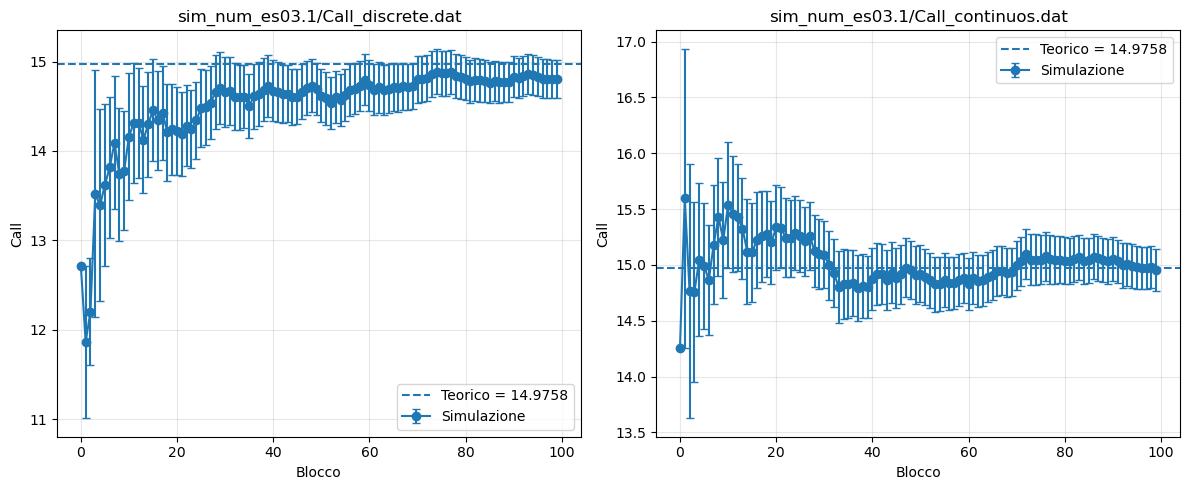

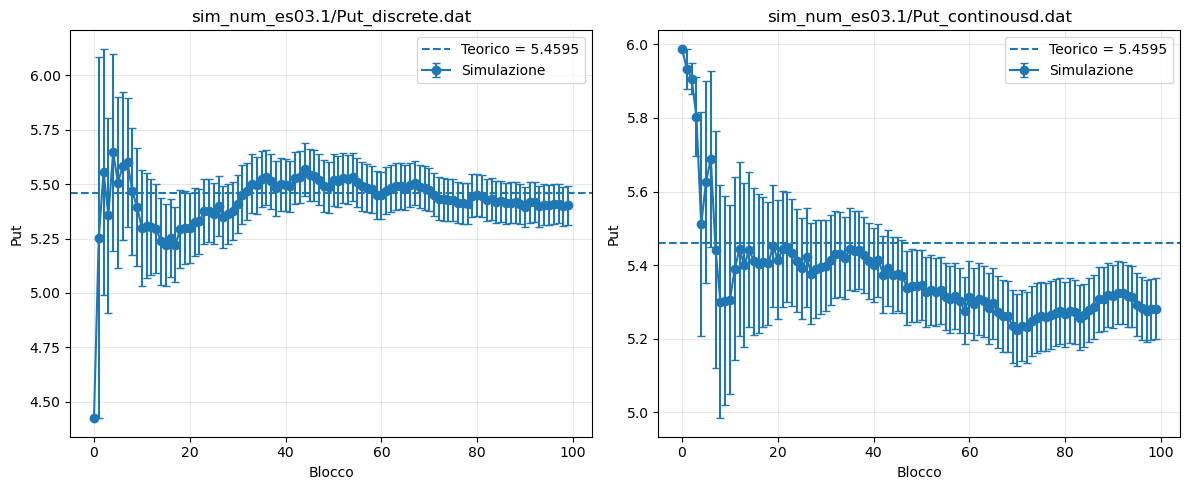

In [11]:
import numpy as np
import matplotlib.pyplot as plt

call_files = [
    "sim_num_es03.1/Call_discrete.dat",
    "sim_num_es03.1/Call_continuos.dat"
]

put_files = [
    "sim_num_es03.1/Put_discrete.dat",
    "sim_num_es03.1/Put_continousd.dat"
]

call_theoretical = 14.975790778311286
put_theoretical = 5.4595325819072364


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, file in zip(axes, call_files):

    data = np.loadtxt(file)

    blocco = data[:, 0]
    valore = data[:, 1]
    errore = data[:, 2]

    ax.errorbar(
        blocco,
        valore,
        yerr=errore,
        fmt='o-',
        capsize=3,
        label='Simulazione'
    )

    ax.axhline(
        call_theoretical,
        linestyle='--',
        label=f'Teorico = {call_theoretical:.4f}'
    )

    ax.set_xlabel("Blocco")
    ax.set_ylabel("Call")
    ax.set_title(file)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, file in zip(axes, put_files):

    data = np.loadtxt(file)

    blocco = data[:, 0]
    valore = data[:, 1]
    errore = data[:, 2]

    ax.errorbar(
        blocco,
        valore,
        yerr=errore,
        fmt='o-',
        capsize=3,
        label='Simulazione'
    )

    ax.axhline(
        put_theoretical,
        linestyle='--',
        label=f'Teorico = {put_theoretical:.4f}'
    )

    ax.set_xlabel("Blocco")
    ax.set_ylabel("Put")
    ax.set_title(file)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()